In [96]:
!pip install pandas numpy matplotlib seaborn

Defaulting to user installation because normal site-packages is not writeable


In [97]:
import pandas as pd
import numpy as np 
import  matplotlib.pyplot as plt # visualizing data
%matplotlib inline
import seaborn as sns

In [98]:
#import csv file
df = pd.read_csv('N:/zomato.csv', encoding = 'unicode_escape')

In [99]:
df.shape

(51717, 17)

In [100]:
df.head()

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


In [101]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [102]:
#check for null values
pd.isnull(df).sum()

url                                0
address                            0
name                               0
online_order                       0
book_table                         0
rate                            7775
votes                              0
phone                           1208
location                          21
rest_type                        227
dish_liked                     28078
cuisines                          45
approx_cost(for two people)      346
reviews_list                       0
menu_item                          0
listed_in(type)                    0
listed_in(city)                    0
dtype: int64

In [103]:
#drop null values
df.dropna(inplace = True)

In [104]:
df.shape

(23193, 17)

In [105]:
df.columns

Index(['url', 'address', 'name', 'online_order', 'book_table', 'rate', 'votes',
       'phone', 'location', 'rest_type', 'dish_liked', 'cuisines',
       'approx_cost(for two people)', 'reviews_list', 'menu_item',
       'listed_in(type)', 'listed_in(city)'],
      dtype='object')

In [106]:
#check and remove duplicates
df.duplicated().sum()

0

In [107]:
#clean rating column
df['rate']= df['rate'].str.replace('/5' , '')

In [108]:
# converts the rate column into numeric datatype (float)
df['rate'] = pd.to_numeric(df['rate'], errors= 'coerce')

In [109]:
#check missing value
df['rate'].isnull().sum()

147

In [110]:
df.isnull().sum()

url                              0
address                          0
name                             0
online_order                     0
book_table                       0
rate                           147
votes                            0
phone                            0
location                         0
rest_type                        0
dish_liked                       0
cuisines                         0
approx_cost(for two people)      0
reviews_list                     0
menu_item                        0
listed_in(type)                  0
listed_in(city)                  0
dtype: int64

In [112]:
#drop null values
df.dropna(subset=['rate'], inplace=True)

In [113]:
print(type(df))

<class 'pandas.core.frame.DataFrame'>


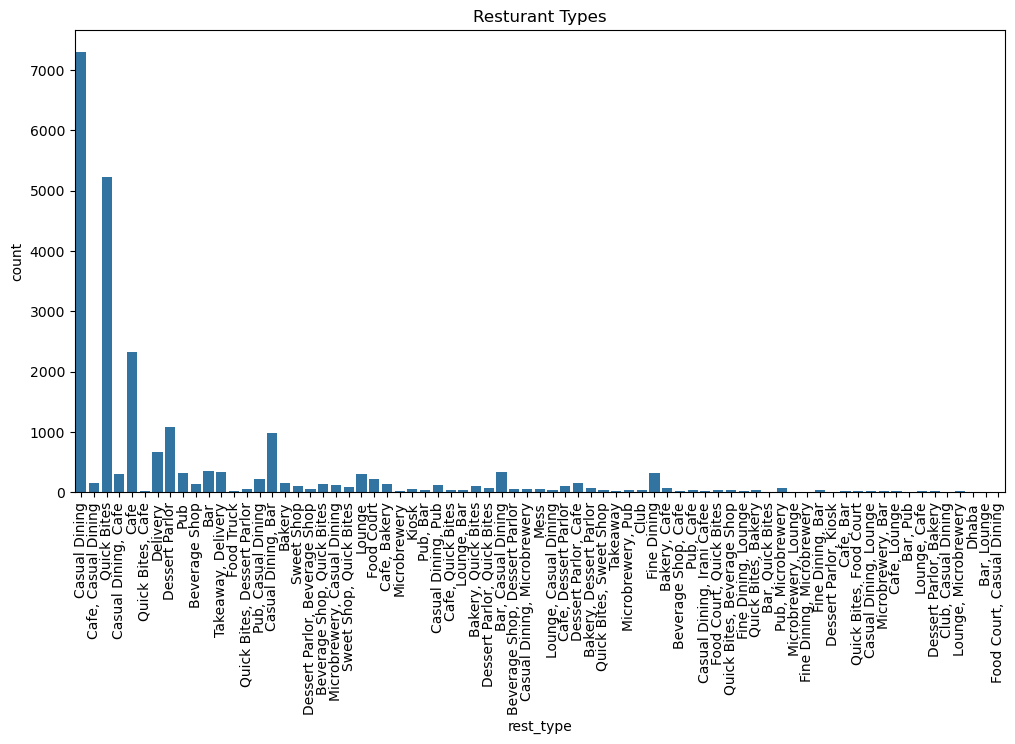

In [116]:
#Exploratory Data Analysis
#figsize=(12,6) → sets graph size
#countplot() → counts occurrences of each restaurant type
#rotation=90 → rotates labels vertically for readability
#title() → adds chart title
#show() → displays the graph

plt.figure(figsize=(12,6))
sns.countplot(x = 'rest_type', data= df)
plt.xticks(rotation = 90)
plt.title("Resturant Types")
plt.show()

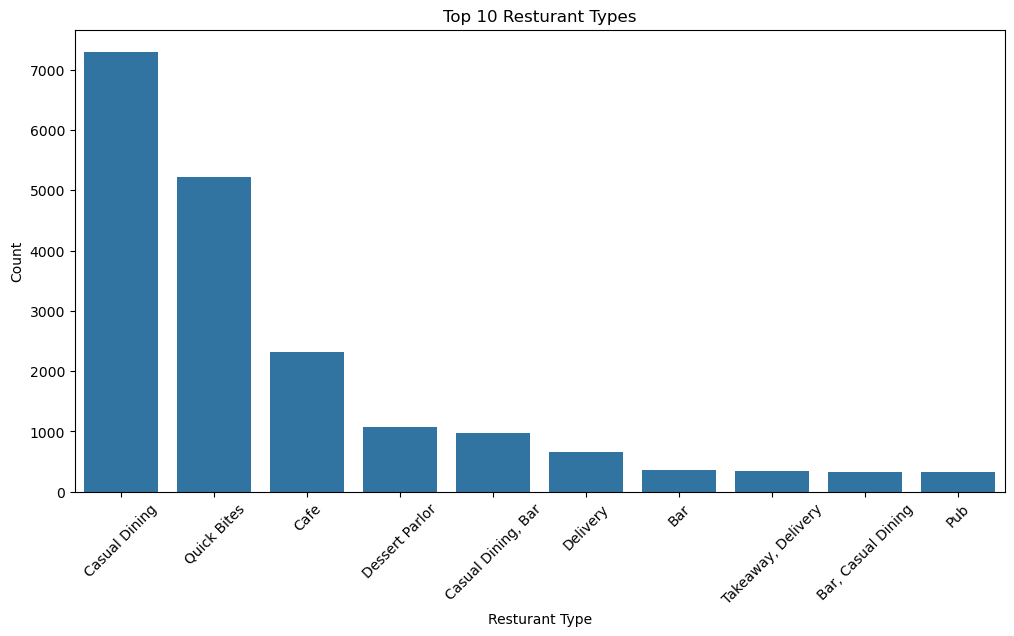

In [121]:
# 1.) Top 10 Restaurant Types
top_types = df['rest_type'].value_counts().head(10)

plt.figure(figsize= (12,6))
sns.barplot( x= top_types.index , y = top_types.values)
plt.xticks(rotation = 45)
plt.title("Top 10 Resturant Types")
plt.xlabel("Resturant Type")
plt.ylabel("Count")

plt.show()
# Casual Dining and Quick Bites are the most common restaurant types.

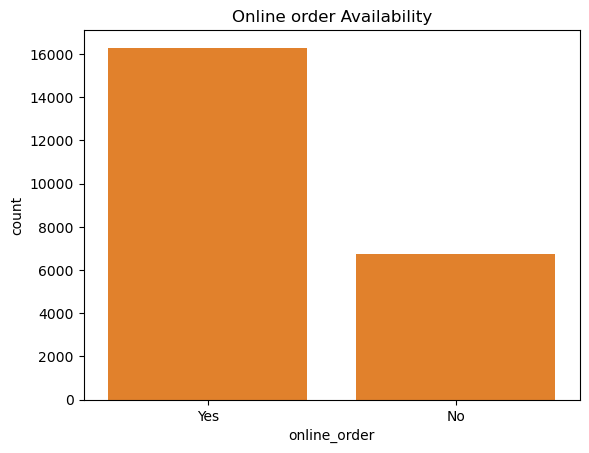

In [123]:
#online order analysis
sns.countplot(x = 'online_order' , data = df)
plt.title("Online order Availability")
plt.show()

#most resturant support online ordering


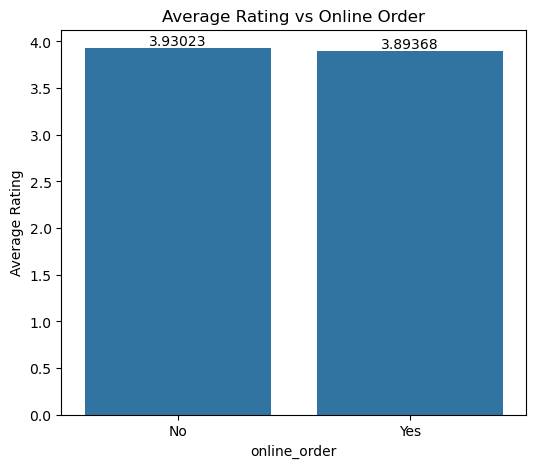

In [149]:
online_order_rating = df.groupby('online_order')['rate'].mean().reset_index()

plt.figure(figsize=(6,5))

ax= sns.barplot( x='online_order', y='rate', data= online_order_rating)

plt.title("Average Rating vs Online Order")
plt.ylabel("Average Rating")
plt.xticks(rotation=0)
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

#Restaurants without online ordering received marginally higher ratings than those with online ordering. The difference was minimal, indicating that online ordering availability does not strongly influence customer ratings.

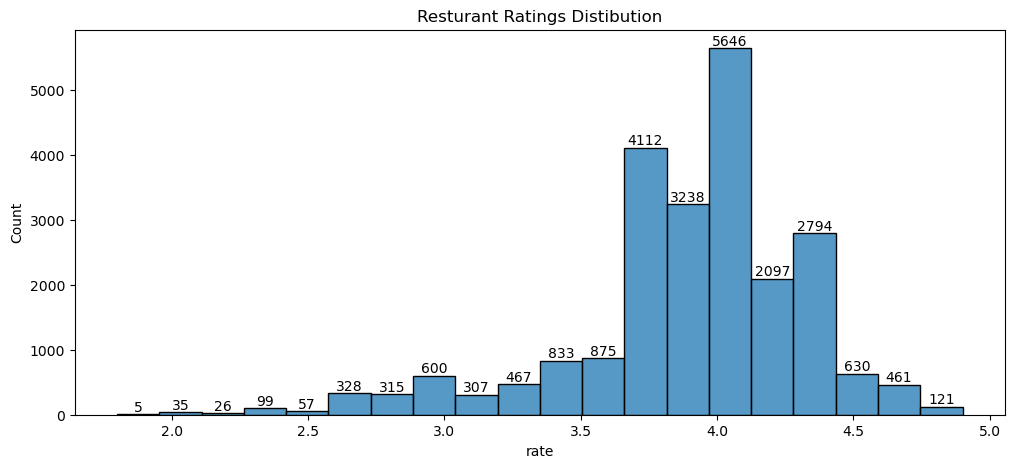

In [155]:
#restaurant ratings distributed across the platform
plt.figure(figsize=(12,5))
ax = sns.histplot(df['rate'] ,bins = 20)
plt.title("Resturant Ratings Distibution")
for bars in ax.containers:
    ax.bar_label(bars)

plt.show()

#Most ratings fall between 3.5 and 4.5.
#Very low-rated restaurants are fewer.


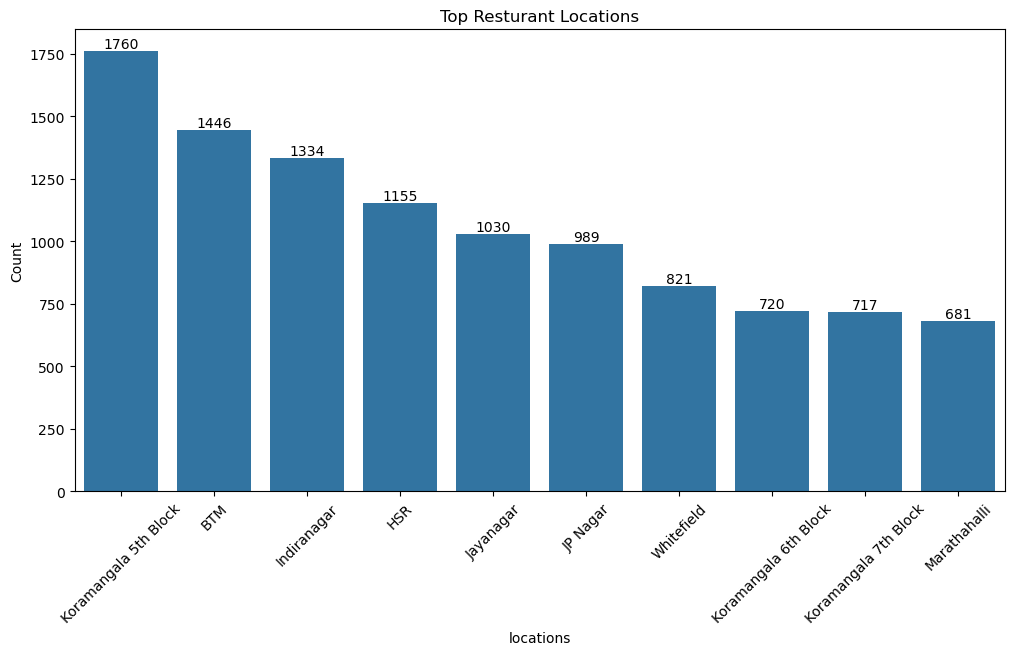

In [162]:
#Top locations
top_locations= df['location'].value_counts().head(10)

plt.figure(figsize= (12,6))
ax = sns.barplot( x = top_locations.index , y = top_locations.values)

plt.xticks(rotation = 45)
plt.title("Top Resturant Locations")
plt.xlabel("locations")
plt.ylabel("Count")
for bars in ax.containers:
    ax.bar_label(bars)


plt.show()

#Certain areas contain significantly higher restaurant density.

In [168]:
#cost distribution
#since cost is in object so convert it into int data type

df['approx_cost(for two people)'] = df['approx_cost(for two people)'].str.replace(',' , '')
df['approx_cost(for two people)'] = pd.to_numeric( df['approx_cost(for two people)'], errors='coerce')


#sns.boxplot(x=df['approx_cost(for two people)'], data = df)
#plt.show()

In [169]:
df['approx_cost(for two people)'].isnull().sum()

0

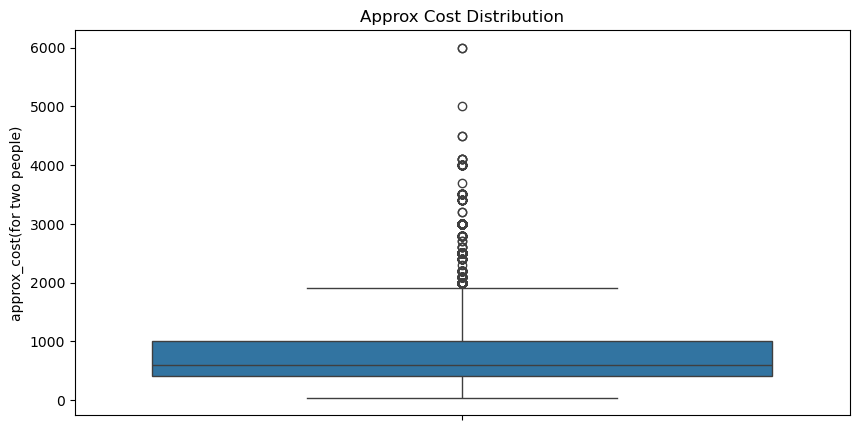

In [178]:
plt.figure(figsize = (10,5))
ax = sns.boxplot(y=df['approx_cost(for two people)'], data = df)
plt.title("Approx Cost Distribution")


plt.show()

#The platform primarily targets middle-income consumers seeking affordable dining options.
#The boxplot of approximate restaurant cost revealed that most restaurants fall within a moderate pricing range. A few restaurants showed extremely high pricing, indicating the presence of outliers in the dataset.

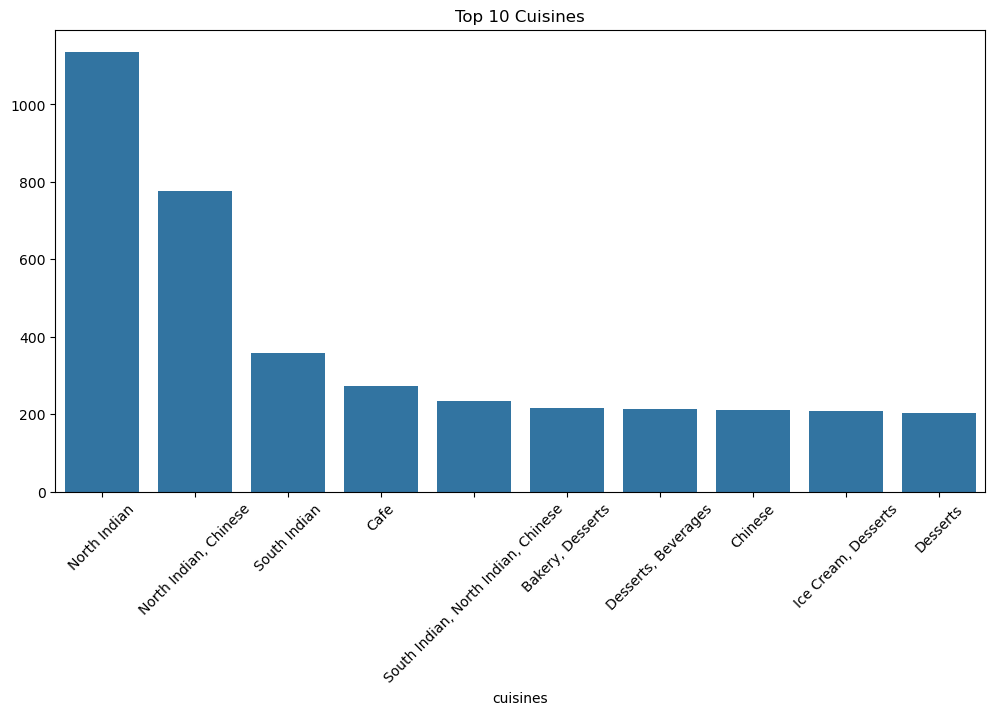

In [186]:
#which cuisine are most popular

top_cuisines = df['cuisines'].value_counts().head(10)

plt.figure(figsize= (12,6))
ax = sns.barplot(x= top_cuisines.index, y = top_cuisines.values )
plt.xticks(rotation = 45)
plt.title("Top 10 Cuisines")
plt.show()

#North Indian cuisine appears most frequently

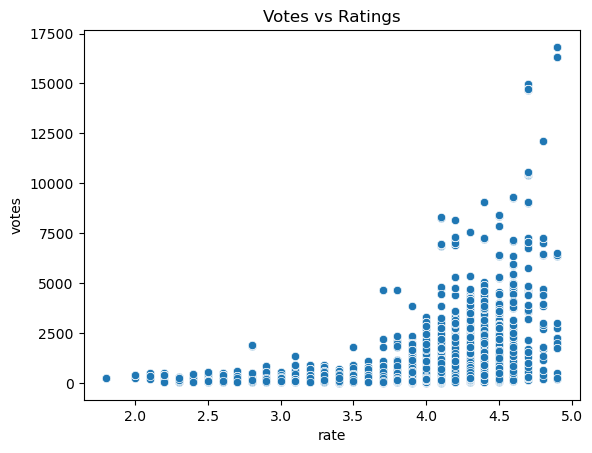

In [195]:
# is there a relationship between votes and ratings

sns. scatterplot(y = 'votes' , x = 'rate' , data = df)
plt.title("Votes vs Ratings")
plt.show()

# positive correlation
#Restaurants with more votes tend to have higher ratings